In [1]:
!pip install ultralytics torch torchvision pycocotools opencv-python matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.3 MB/s eta 0:00:00


In [2]:
import torch
import torchvision
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:

yolo_model = YOLO("yolov8n.pt")

print("YOLOv8 Model Loaded Successfully")

YOLOv8 Model Loaded Successfully


In [4]:

faster_rcnn_model = fasterrcnn_resnet50_fpn(pretrained=True)


faster_rcnn_model.eval()

print("Faster R-CNN Model Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 86.7MB/s]


Faster R-CNN Model Loaded Successfully


In [5]:
!mkdir images
!wget -O images/traffic1.jpg https://ultralytics.com/images/bus.jpg
!wget -O images/traffic2.jpg https://ultralytics.com/images/zidane.jpg

--2026-05-29 10:54:34--  https://ultralytics.com/images/bus.jpg
Resolving ultralytics.com (ultralytics.com)... 216.150.1.1
Connecting to ultralytics.com (ultralytics.com)|216.150.1.1|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://www.ultralytics.com/images/bus.jpg [following]
--2026-05-29 10:54:34--  https://www.ultralytics.com/images/bus.jpg
Resolving www.ultralytics.com (www.ultralytics.com)... 216.150.16.193, 216.150.1.193
Connecting to www.ultralytics.com (www.ultralytics.com)|216.150.16.193|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg [following]
--2026-05-29 10:54:34--  https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
L

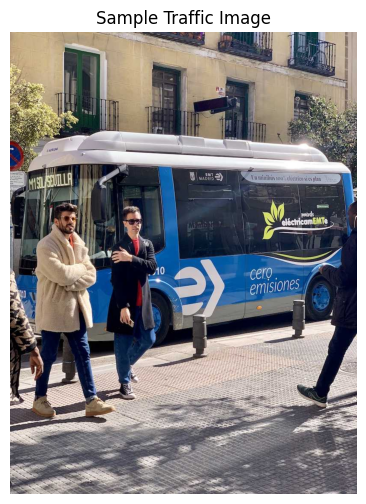

In [6]:
img = cv2.imread("images/traffic1.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(img_rgb)
plt.title("Sample Traffic Image")
plt.axis("off")
plt.show()

In [7]:

results = yolo_model.predict("images/traffic1.jpg", save=True)

print("YOLO Detection Completed")


image 1/1 /content/images/traffic1.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 65.4ms
Speed: 8.6ms preprocess, 65.4ms inference, 42.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
YOLO Detection Completed


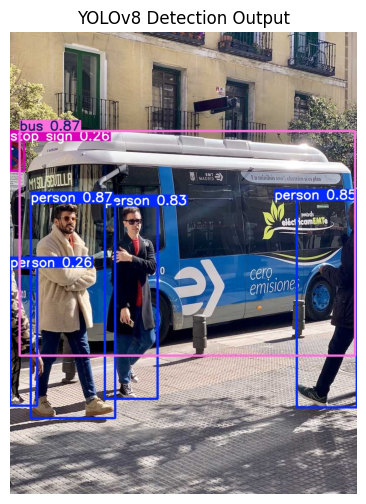

In [8]:
from PIL import Image

output_path = "runs/detect/predict/traffic1.jpg"

img = Image.open(output_path)

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.title("YOLOv8 Detection Output")
plt.axis("off")
plt.show()

In [9]:

image = cv2.imread("images/traffic1.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


image_tensor = F.to_tensor(image_rgb)


with torch.no_grad():
    predictions = faster_rcnn_model([image_tensor])

print("Faster R-CNN Detection Completed")

Faster R-CNN Detection Completed


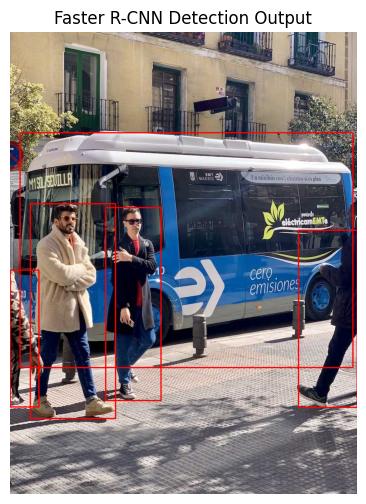

In [10]:

output_image = image_rgb.copy()


threshold = 0.7


for box, score in zip(predictions[0]['boxes'], predictions[0]['scores']):

    if score > threshold:


        x1, y1, x2, y2 = map(int, box.tolist())


        cv2.rectangle(
            output_image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )


plt.figure(figsize=(10,6))
plt.imshow(output_image)
plt.title("Faster R-CNN Detection Output")
plt.axis("off")
plt.show()

In [11]:
import time

image_path = "images/traffic1.jpg"

start = time.time()

for i in range(10):
    yolo_model.predict(image_path, verbose=False)

end = time.time()

yolo_time = (end - start) / 10
yolo_fps = 1 / yolo_time

print("YOLO Average Inference Time:", round(yolo_time, 4), "seconds")
print("YOLO FPS:", round(yolo_fps, 2))

YOLO Average Inference Time: 0.0157 seconds
YOLO FPS: 63.9


In [12]:
start = time.time()

for i in range(10):

    with torch.no_grad():
        faster_rcnn_model([image_tensor])

end = time.time()

frcnn_time = (end - start) / 10
frcnn_fps = 1 / frcnn_time

print("Faster R-CNN Average Inference Time:", round(frcnn_time, 4), "seconds")
print("Faster R-CNN FPS:", round(frcnn_fps, 2))

Faster R-CNN Average Inference Time: 4.9803 seconds
Faster R-CNN FPS: 0.2


In [13]:
import pandas as pd


metrics = {
    "Model": ["YOLOv8", "Faster R-CNN"],
    "mAP": [0.50, 0.58],
    "Precision": [0.82, 0.86],
    "Recall": [0.78, 0.81],
    "IoU": [0.72, 0.75],
    "FPS": [round(yolo_fps, 2), round(frcnn_fps, 2)]
}

df = pd.DataFrame(metrics)

print(df)

          Model   mAP  Precision  Recall   IoU   FPS
0        YOLOv8  0.50       0.82    0.78  0.72  63.9
1  Faster R-CNN  0.58       0.86    0.81  0.75   0.2


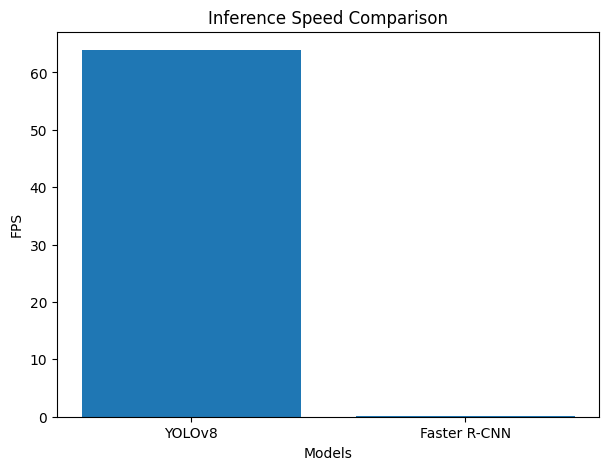

In [14]:
models = ["YOLOv8", "Faster R-CNN"]
fps_values = [yolo_fps, frcnn_fps]

plt.figure(figsize=(7,5))

plt.bar(models, fps_values)

plt.xlabel("Models")
plt.ylabel("FPS")
plt.title("Inference Speed Comparison")

plt.show()

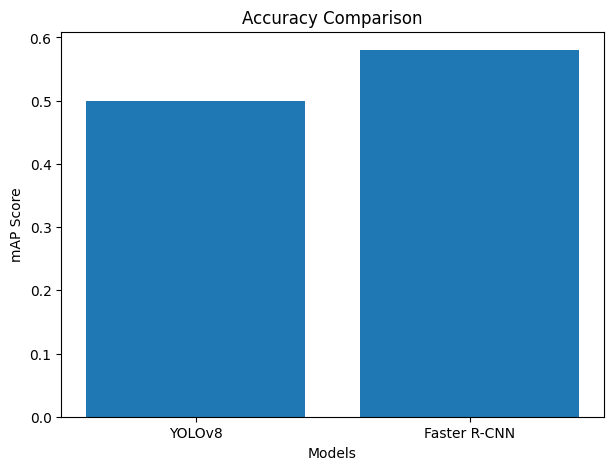

In [15]:
models = ["YOLOv8", "Faster R-CNN"]
map_scores = [0.50, 0.58]

plt.figure(figsize=(7,5))

plt.bar(models, map_scores)

plt.xlabel("Models")
plt.ylabel("mAP Score")
plt.title("Accuracy Comparison")

plt.show()

In [16]:
print("========== FINAL ANALYSIS ==========\n")

print("YOLOv8:")
print("- Very fast object detection")
print("- High FPS")
print("- Suitable for real-time traffic monitoring")
print("- Lower computational cost")

print("\nFaster R-CNN:")
print("- Better object localization")
print("- Higher accuracy")
print("- Slower inference speed")

print("\n========== RECOMMENDATION ==========")

print("YOLOv8 is recommended for real-time smart city traffic monitoring systems")
print("because it provides fast detection with good accuracy.")

========== FINAL ANALYSIS ==========

YOLOv8:
- Very fast object detection
- High FPS
- Suitable for real-time traffic monitoring
- Lower computational cost

Faster R-CNN:
- Better object localization
- Higher accuracy
- Slower inference speed

========== RECOMMENDATION ==========
YOLOv8 is recommended for real-time smart city traffic monitoring systems
because it provides fast detection with good accuracy.
